In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
column_names = [
    "userId",
    "movieId",
    "categoryId",
    "reviewId",
    "rating",
    "reviewDate"
]

df = pd.read_csv(
    "../data/raw/movie-ratings.txt",
    sep=",",
    names=column_names,
    header=None
)

print("Dataset loaded successfully.")
print(df.head())
print(df.shape)

Dataset loaded successfully.
   userId  movieId  categoryId  reviewId  rating  reviewDate
0       1        1           1         1       5  2000-07-12
1       2        1           1         2       5  2000-07-12
2       3        1           1         3       5  2000-07-12
3       4        1           1         4       4  2000-07-12
4       5        1           1         5       4  2000-07-12
(72665, 6)


In [4]:
num_users = df["userId"].nunique()
num_movies = df["movieId"].nunique()
num_ratings = len(df)

sparsity = (1 - (num_ratings / (num_users * num_movies))) * 100

print(f"Number of Users: {num_users}")
print(f"Number of Movies: {num_movies}")
print(f"Number of Ratings: {num_ratings}")
print(f"Sparsity of Rating Matrix: {sparsity:.2f}%")

Number of Users: 17615
Number of Movies: 16121
Number of Ratings: 72665
Sparsity of Rating Matrix: 99.97%


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
userId        0
movieId       0
categoryId    0
reviewId      0
rating        0
reviewDate    0
dtype: int64

Duplicate Rows:
0


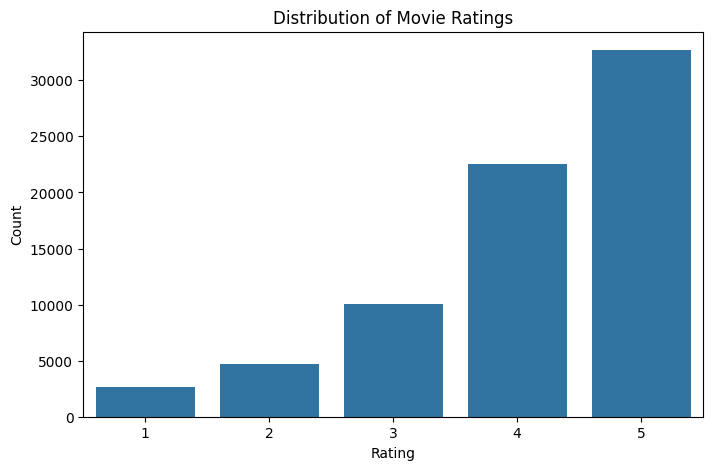

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x="rating", data=df)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

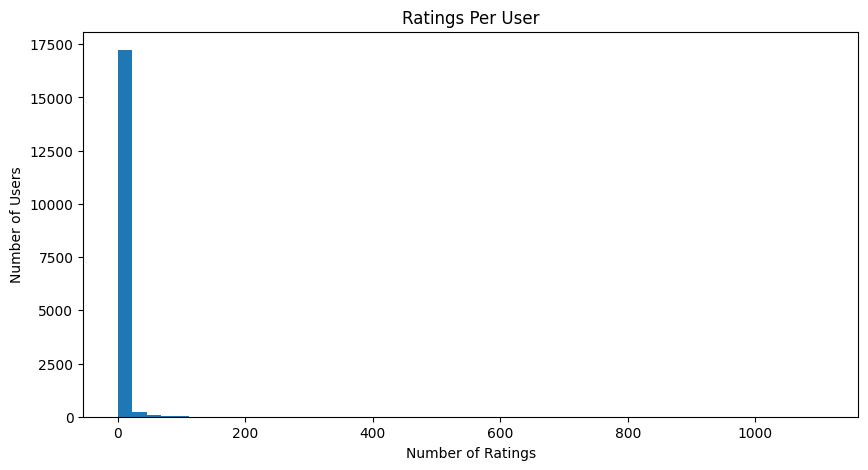

In [7]:
ratings_per_user = df.groupby("userId")["rating"].count()

plt.figure(figsize=(10,5))
plt.hist(ratings_per_user, bins=50)

plt.title("Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

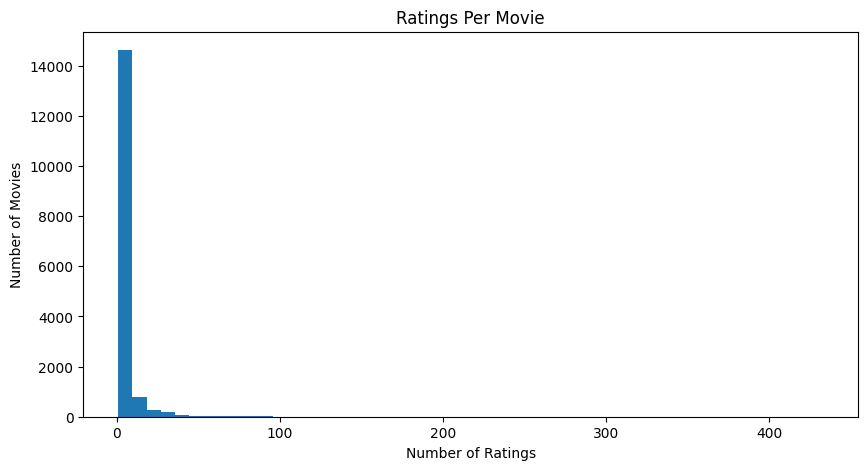

In [8]:
ratings_per_movie = df.groupby("movieId")["rating"].count()

plt.figure(figsize=(10,5))
plt.hist(ratings_per_movie, bins=50)

plt.title("Ratings Per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.show()

## Key Findings from EDA

- The dataset contains 72,665 movie ratings from 17,615 users and 16,121 movies.
- The rating matrix is extremely sparse, with a sparsity of 99.97%.
- There are no missing values in the dataset.
- There are no duplicate rows in the dataset.
- The rating distribution is skewed toward higher ratings, especially 4-star and 5-star ratings.
- Ratings per user and ratings per movie both show a long-tail pattern: most users rate only a few movies, and most movies receive only a few ratings.